In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tsfresh
from tsfresh import extract_relevant_features
from tsfresh.feature_extraction import extract_features
from tsfresh.transformers import FeatureSelector
from tsfresh.utilities.dataframe_functions import impute
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

In [2]:
walk = pd.read_csv("walking.csv")
run = pd.read_csv("running.csv")

print(walk.head())
print(run.head())

   time    ax    ay    az  atotal
0  0.00 -0.15  0.26 -0.39    0.49
1  0.01 -0.13  0.18  0.10    0.25
2  0.02 -0.04  0.11  0.41    0.43
3  0.03  0.01  0.09  0.44    0.45
4  0.04 -0.03  0.11  0.30    0.32
   time    ax    ay    az  atotal
0  0.00 -0.80  3.63 -0.22    3.72
1  0.01 -1.13  3.69 -0.47    3.89
2  0.02 -0.86  3.72 -0.53    3.86
3  0.03 -0.57  3.31 -0.44    3.39
4  0.04 -0.47  3.04  0.39    3.10


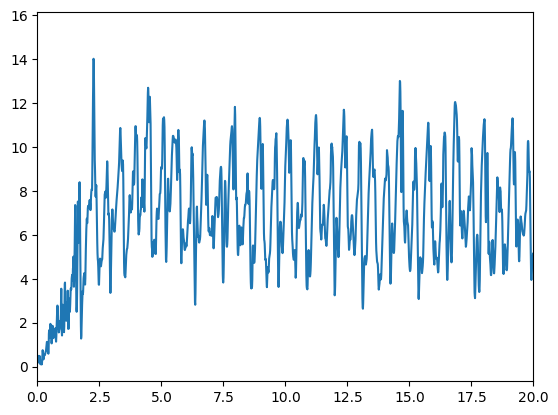

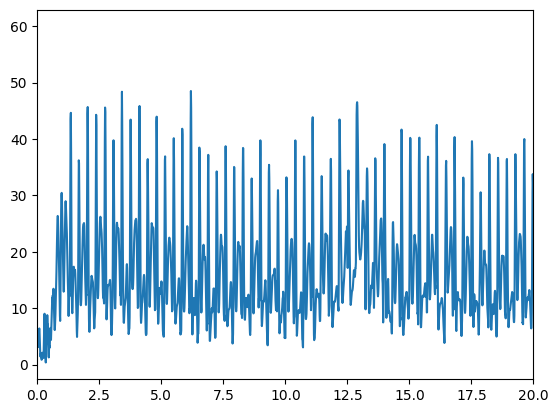

In [3]:
plt.plot(walk.time, walk.atotal)
plt.xlim(0, 20)
plt.show()
plt.plot(run.time, run.atotal)
plt.xlim(0, 20)
plt.show()

In [4]:
walk = walk[(walk.time > 2.5) & (walk.time < 185)]
run = run[(run.time > 2.5) & (run.time < 130)]
walk = walk.reset_index(drop=True)
run = run.reset_index(drop=True)

In [5]:
walk["window_idx"] = "walk_" + (walk.index // 100).astype(str)
run["window_idx"] = "run_" + (run.index // 100).astype(str)

In [6]:
walk_X = extract_features(walk, column_id="window_idx", column_sort="time")
run_X = extract_features(run, column_id="window_idx", column_sort="time")
# Takes input y -> need to do altogether defineds
# walk_X = extract_relevant_features(walk, column_id="window_idx", column_sort="time")
# run_X = extract_relevant_features(run, column_id="window_idx", column_sort="time")
# Generates basially everything about the signal
X = pd.concat([walk_X, run_X])
y = pd.Series(
    [0] * len(walk_X) + [1] * len(run_X),
    index=X.index
)
print(X.shape)
print(y.shape)
print(X.index.equals(y.index))

Feature Extraction: 100%|██████████| 43/43 [00:10<00:00,  4.05it/s]


(311, 3132)
(311,)
True


In [7]:
X = X.dropna(axis=1)

In [8]:
select = FeatureSelector()
select.fit(X, y)

# 3.4s was the last run - is time an issue? 
# Works via hypothesis testing, alternative is what we did with relevance/covariance table

,test_for_binary_target_binary_feature,'fisher'
,test_for_binary_target_real_feature,'mann'
,test_for_real_target_binary_feature,'mann'
,test_for_real_target_real_feature,'kendall'
,fdr_level,0.05
,hypotheses_independent,False
,n_jobs,9
,chunksize,None
,ml_task,'auto'
,multiclass,False
,n_significant,1


ax__fft_coefficient__attr_"real"__coeff_14    0.0
ax__fft_coefficient__attr_"real"__coeff_15    0.0
ax__fft_coefficient__attr_"real"__coeff_16    0.0
ax__fft_coefficient__attr_"real"__coeff_17    0.0
ax__fft_coefficient__attr_"real"__coeff_18    0.0
dtype: float64


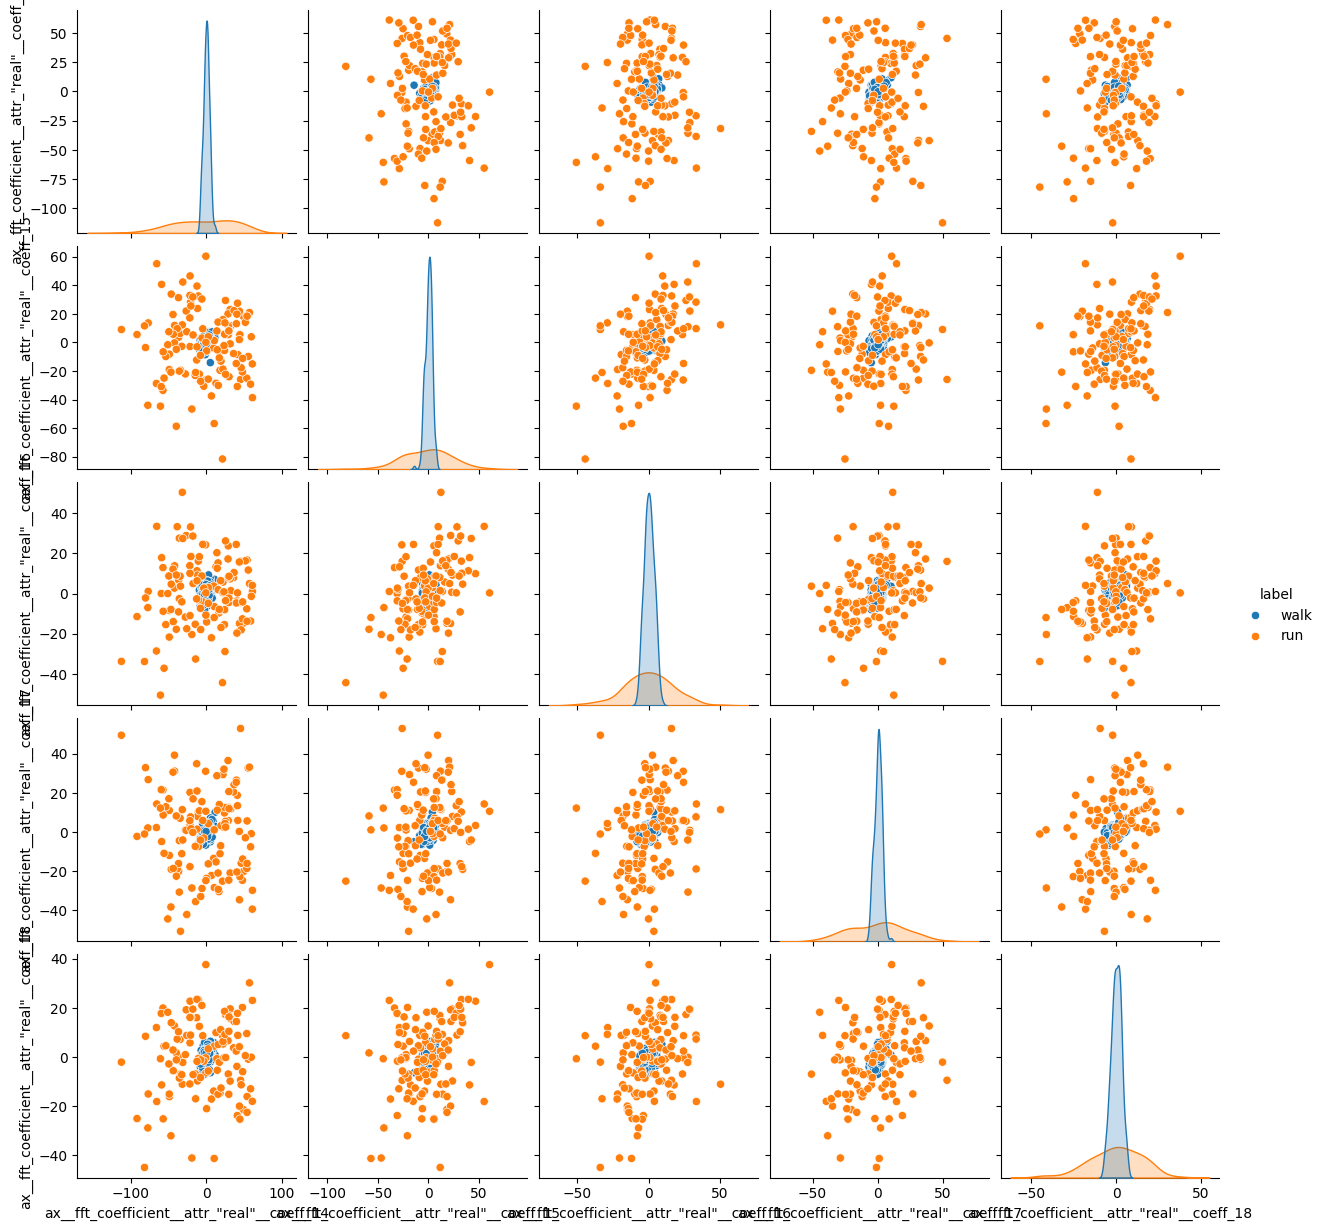

In [9]:
pvals = pd.Series(select.feature_importances_, index=X.columns)
top5 = pvals.nsmallest(5)
print(top5)
top5_features = top5.index
X_top5 = X[top5_features]
plot_df = X_top5.copy()
plot_df["label"] = y.map({0: "walk", 1: "run"})
sns.pairplot(plot_df, hue="label")
plt.show()

In [ ]:


forest = RandomForestClassifier()
cv = RepeatedStratifiedKFold(
    n_splits=10,            # 10-fold
    n_repeats=10           # repeat 10 times
)
scores = cross_val_score(forest, X_sig, y, cv=cv, scoring='accuracy')

print("Mean accuracy: {:.3f}".format(np.mean(scores)))
print("Standard deviation: {:.3f}".format(np.std(scores)))

NameError: name 'RandomForestClassifier' is not defined

ax__change_quantiles__f_agg_"var"__isabs_True__qh_0.8__ql_0.6     0.110000
ax__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.6    0.103069
ax__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.8     0.096304
ax__change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.8    0.095635
ax__change_quantiles__f_agg_"var"__isabs_False__qh_1.0__ql_0.6    0.090000
dtype: float64


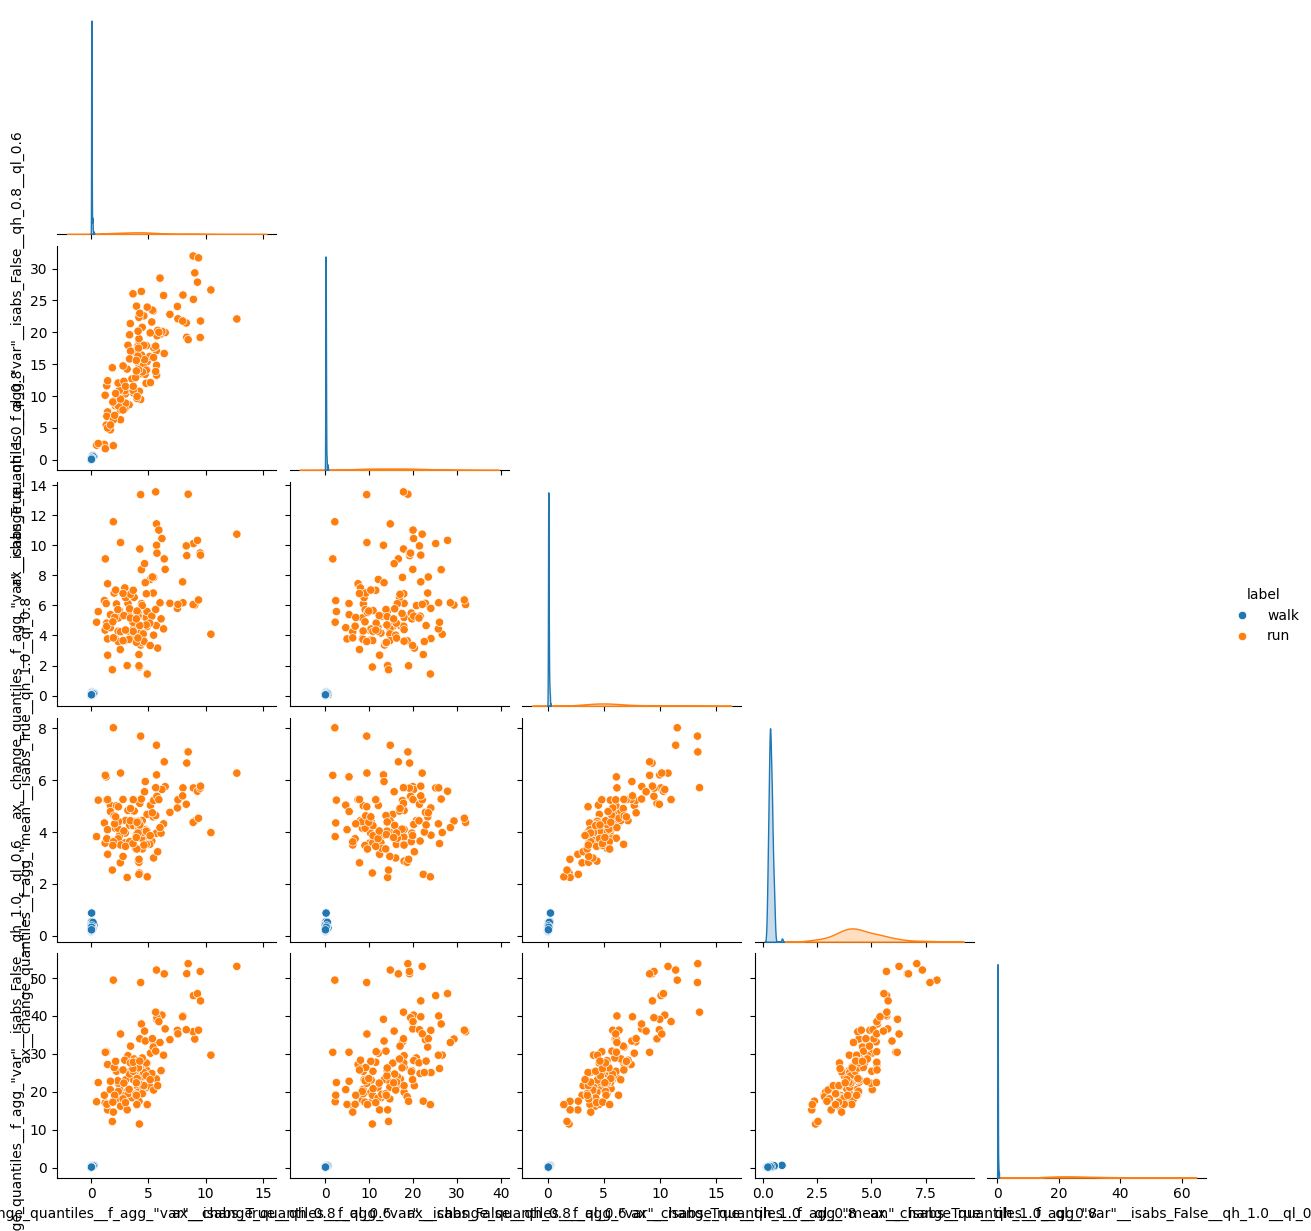

In [11]:
forest.fit(X_sig, y)
feat_imp = pd.Series(forest.feature_importances_, index=X_sig.columns)
top5_features = feat_imp.nlargest(5)
print(top5_features)
X_top5 = X_sig[top5_features.index]
plot_df = X_top5.copy()
plot_df["label"] = y.map({0: "walk", 1: "run"})
sns.pairplot(plot_df, hue="label", diag_kind="kde", corner=True)
plt.show()